Training Dataset Shape: (1296675, 23)
Testing Dataset Shape: (555719, 23)

Columns:
Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last  

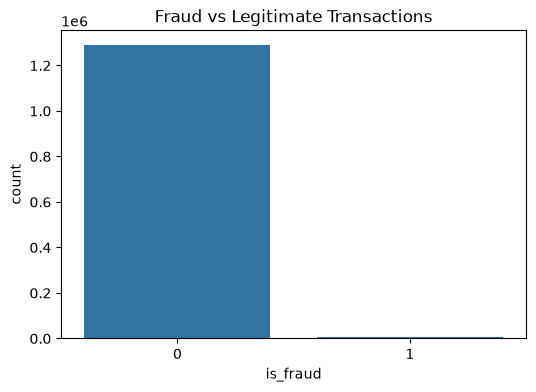

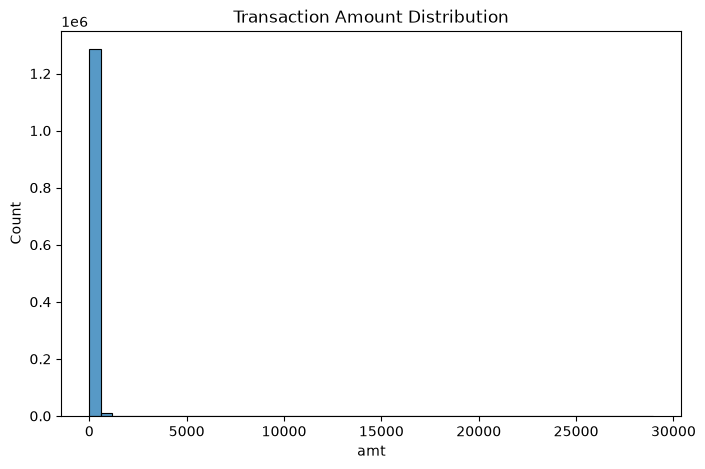

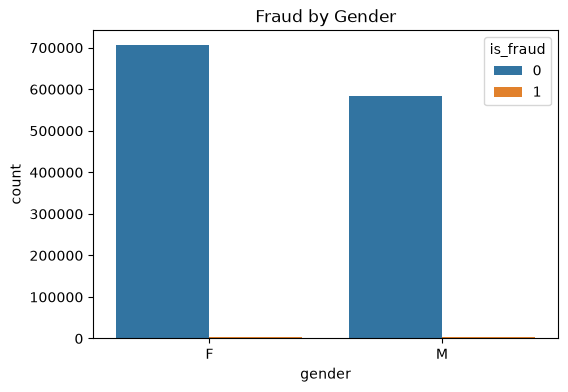

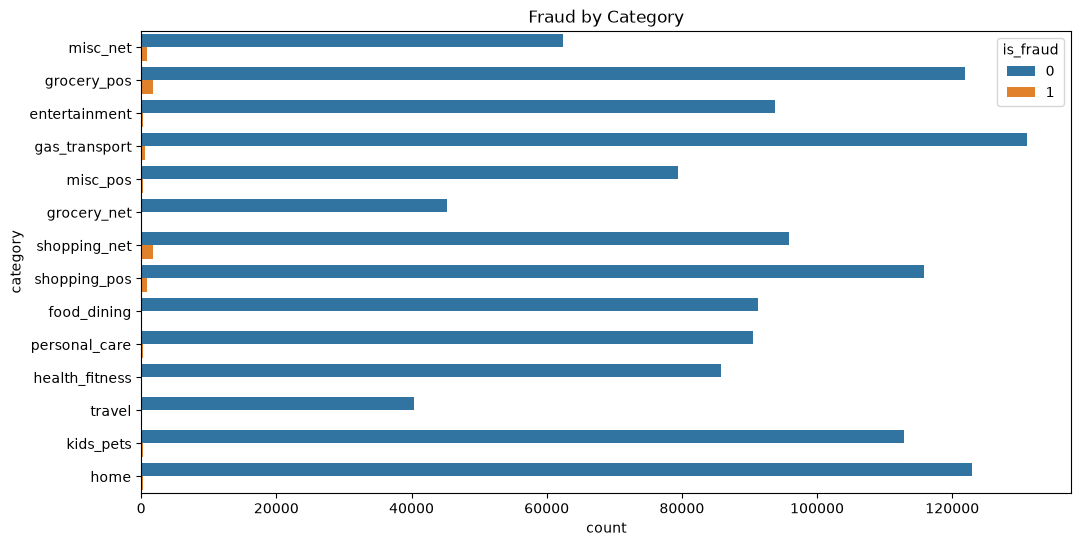

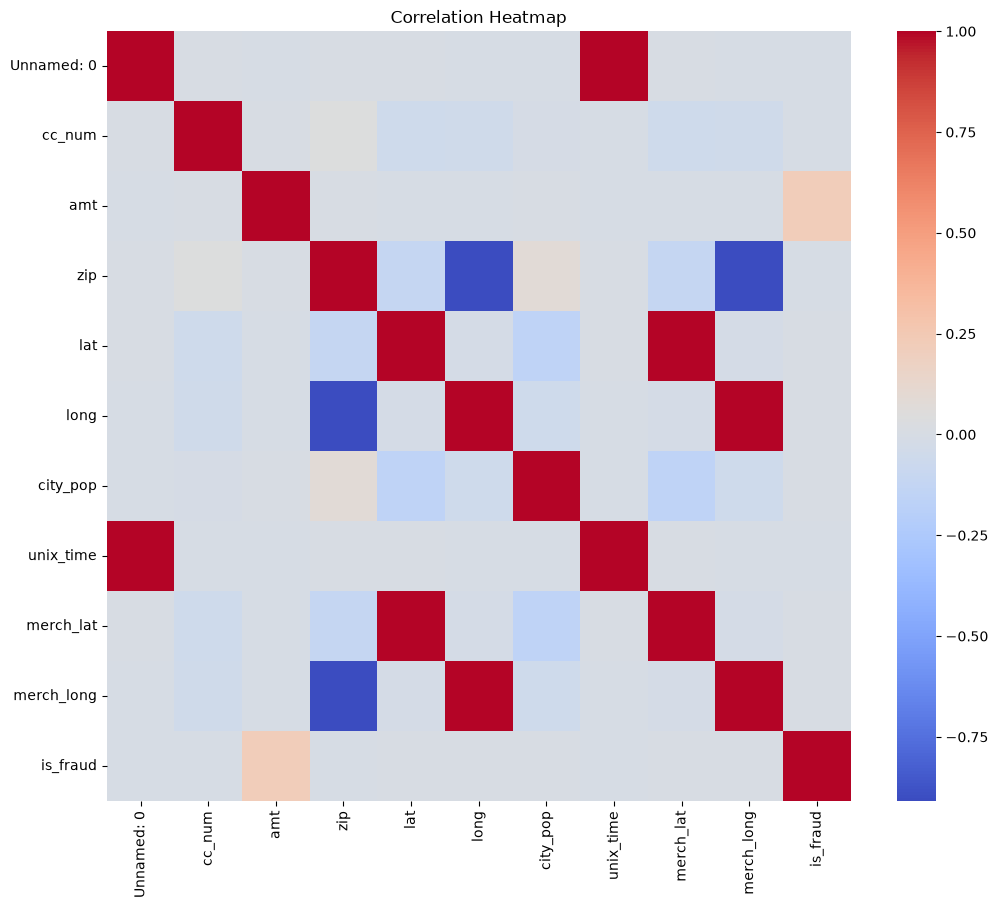


========== Logistic Regression ==========
Accuracy: 0.9557510180504896
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    553574
           1       0.06      0.75      0.12      2145

    accuracy                           0.96    555719
   macro avg       0.53      0.85      0.55    555719
weighted avg       1.00      0.96      0.97    555719


========== Decision Tree ==========
Accuracy: 0.9937072513266597
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.32      0.57      0.41      2145

    accuracy                           0.99    555719
   macro avg       0.66      0.78      0.70    555719
weighted avg       1.00      0.99      0.99    555719


========== Random Forest ==========
Accuracy: 0.9971064512820328
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.91      0.28

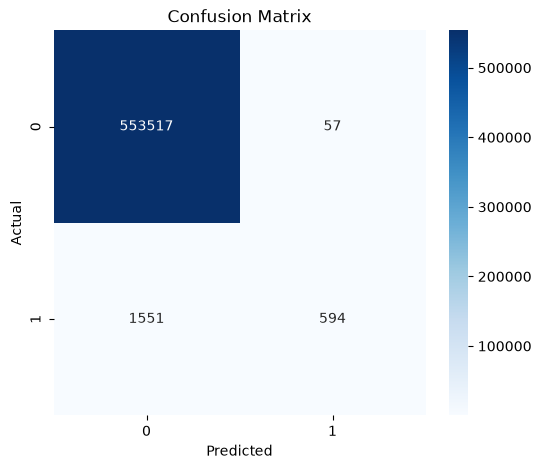


========== Model Comparison ==========
                 Model  Accuracy
0  Logistic Regression  0.955751
1        Decision Tree  0.993707
2        Random Forest  0.997106


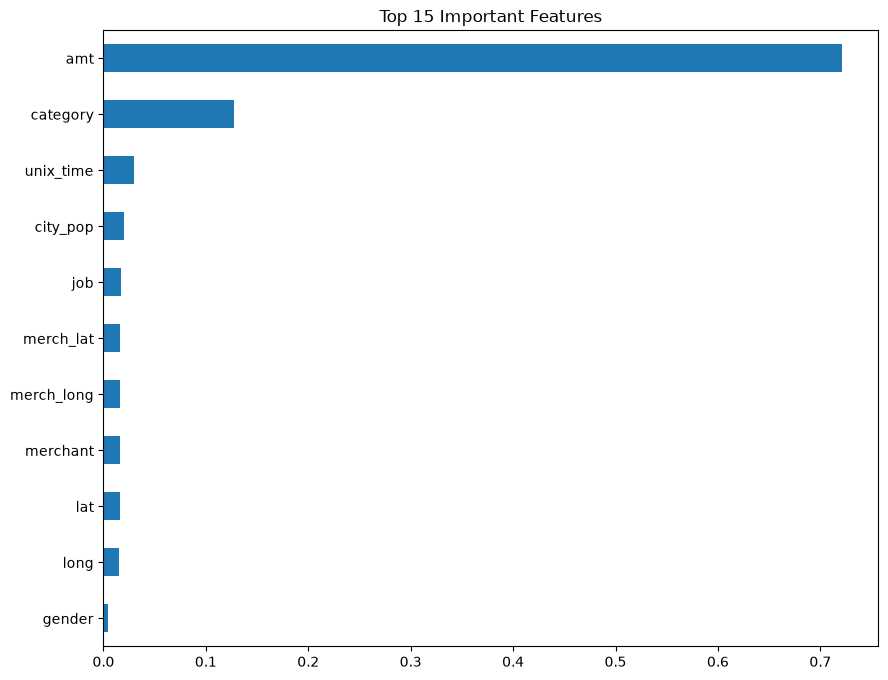


Model saved successfully as fraud_model.pkl

========== Performance ==========
Precision : 0.9124423963133641
Recall    : 0.27692307692307694
F1 Score  : 0.4248927038626609
ROC AUC   : 0.9615294352175059


In [3]:
# ==========================================
# CREDIT CARD FRAUD DETECTION
# ==========================================

# ----------- Import Libraries -----------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# ----------- Load Dataset -----------

train = pd.read_csv("fraudTrain.csv")
test = pd.read_csv("fraudTest.csv")


# ==========================================
# DATA EXPLORATION
# ==========================================

print("Training Dataset Shape:", train.shape)
print("Testing Dataset Shape:", test.shape)

print("\nColumns:")
print(train.columns)

print("\nDataset Information:")
print(train.info())

print("\nMissing Values:")
print(train.isnull().sum())

print("\nDuplicate Rows:", train.duplicated().sum())


# ==========================================
# EXPLORATORY DATA ANALYSIS
# ==========================================

# Fraud Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="is_fraud", data=train)
plt.title("Fraud vs Legitimate Transactions")
plt.show()

# Transaction Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(train["amt"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

# Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="is_fraud", data=train)
plt.title("Fraud by Gender")
plt.show()

# Category Distribution
plt.figure(figsize=(12,6))
sns.countplot(y="category", hue="is_fraud", data=train)
plt.title("Fraud by Category")
plt.show()

# Correlation Heatmap
numeric = train.select_dtypes(include=np.number)

plt.figure(figsize=(12,10))
sns.heatmap(numeric.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# ==========================================
# DATA CLEANING
# ==========================================

drop_columns = [
    "Unnamed: 0",
    "trans_date_trans_time",
    "cc_num",
    "first",
    "last",
    "street",
    "city",
    "state",
    "zip",
    "dob",
    "trans_num"
]

train.drop(columns=drop_columns, inplace=True, errors="ignore")
test.drop(columns=drop_columns, inplace=True, errors="ignore")


# ==========================================
# ENCODE CATEGORICAL FEATURES
# ==========================================

categorical_columns = train.select_dtypes(include=["object", "string"]).columns

for col in categorical_columns:
    encoder = LabelEncoder()

    combined = pd.concat([train[col], test[col]], axis=0)

    encoder.fit(combined)

    train[col] = encoder.transform(train[col])
    test[col] = encoder.transform(test[col])


# ==========================================
# PREPARE FEATURES
# ==========================================

X_train = train.drop("is_fraud", axis=1)
y_train = train["is_fraud"]

X_test = test.drop("is_fraud", axis=1)
y_test = test["is_fraud"]


# ==========================================
# LOGISTIC REGRESSION
# ==========================================

print("\n========== Logistic Regression ==========")

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))


# ==========================================
# DECISION TREE
# ==========================================

print("\n========== Decision Tree ==========")

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_dt))
print(classification_report(y_test, pred_dt))


# ==========================================
# RANDOM FOREST
# ==========================================

print("\n========== Random Forest ==========")

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))


# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# ==========================================
# MODEL COMPARISON
# ==========================================

results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf)
    ]

})

print("\n========== Model Comparison ==========")
print(results)


# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,8))

importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Important Features")

plt.show()


# ==========================================
# SAVE MODEL
# ==========================================

joblib.dump(rf, "fraud_model.pkl")

print("\nModel saved successfully as fraud_model.pkl")


# ==========================================
# PERFORMANCE METRICS
# ==========================================

probabilities = rf.predict_proba(X_test)[:, 1]

print("\n========== Performance ==========")

print("Precision :", precision_score(y_test, pred_rf))
print("Recall    :", recall_score(y_test, pred_rf))
print("F1 Score  :", f1_score(y_test, pred_rf))
print("ROC AUC   :", roc_auc_score(y_test, probabilities))